# Analisis 5W+1H - Chicago Crime (Part 3: WHY)

Bagian ini berfokus pada **WHY (Mengapa)**, mencoba menggali hubungan dan korelasi antar fitur untuk mendapatkan inferensi tentang penyebab atau pemicu kejahatan.

In [8]:
import pandas as pd
import numpy as np
import matplotlib
# matplotlib.use('Agg') # Tidak diperlukan di notebook, plot akan tampil inline
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
import warnings, os

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.size'] = 10
sns.set_style('whitegrid')

# Pastikan direktori output ada
OUT = r'c:\Python\Data_Mining\output_5w1h'
os.makedirs(OUT, exist_ok=True)

print("Setup selesai.")

Setup selesai.


In [10]:
# Load data (Fallback ke CSV jika pickle dari Part 1 belum ada)
pickle_path = f'{OUT}/_temp_df.pkl'

if os.path.exists(pickle_path):
    df = pd.read_pickle(pickle_path)
    print(f"Data berhasil dimuat dari pickle: {len(df):,} baris.")
else:
    print("File pickle tidak ditemukan. Memuat dari Mining.csv dan melakukan preprocessing...")
    cols = ['Date','Primary Type','Description','Location Description',
            'Arrest','Domestic','District','Ward','Community Area',
            'Year','Latitude','Longitude','Beat','IUCR','FBI Code','Block']
    df = pd.read_csv(r'c:\Python\Data_Mining\Mining.csv', usecols=cols, nrows=500000, low_memory=False)
    df = df.sample(n=300000, random_state=42).reset_index(drop=True)

    df['Date'] = pd.to_datetime(df['Date'], format='mixed', errors='coerce')
    df['Hour'] = df['Date'].dt.hour
    df['DayOfWeek'] = df['Date'].dt.dayofweek
    df['Month'] = df['Date'].dt.month
    df['IsNight'] = df['Hour'].apply(lambda x: 1 if (x >= 22 or x < 6) else 0)
    df['IsWeekend'] = df['DayOfWeek'].apply(lambda x: 1 if x >= 5 else 0)

    df.to_pickle(pickle_path)
    print(f"Pre-processing selesai. Data disimpan ke pickle. Sample: {len(df):,} rows.")


Data berhasil dimuat dari pickle: 300,000 baris.


---
## OPSI 5: WHY - Mengapa Kejahatan Terjadi? (Inferensi)
---


[5.1] Probabilitas Bersyarat P(Arrest | Kondisi):
  Kondisi                              P(Arrest)         N
  -------------------------------------------------------
  Malam Hari (IsNight=1)                  25.28%    83,600
  Siang Hari (IsNight=0)                  27.04%   216,400
  Weekend                                 25.41%    84,326
  Weekday                                 27.00%   215,674
  Domestic=True                           21.26%    47,108
  Domestic=False                          27.54%   252,892
  Lokasi: STREET                          27.78%    94,515
  Lokasi: APARTMENT                       15.86%    24,803
  Lokasi: RESIDENCE                       15.92%    50,115
  Lokasi: SIDEWALK                        45.11%    17,363


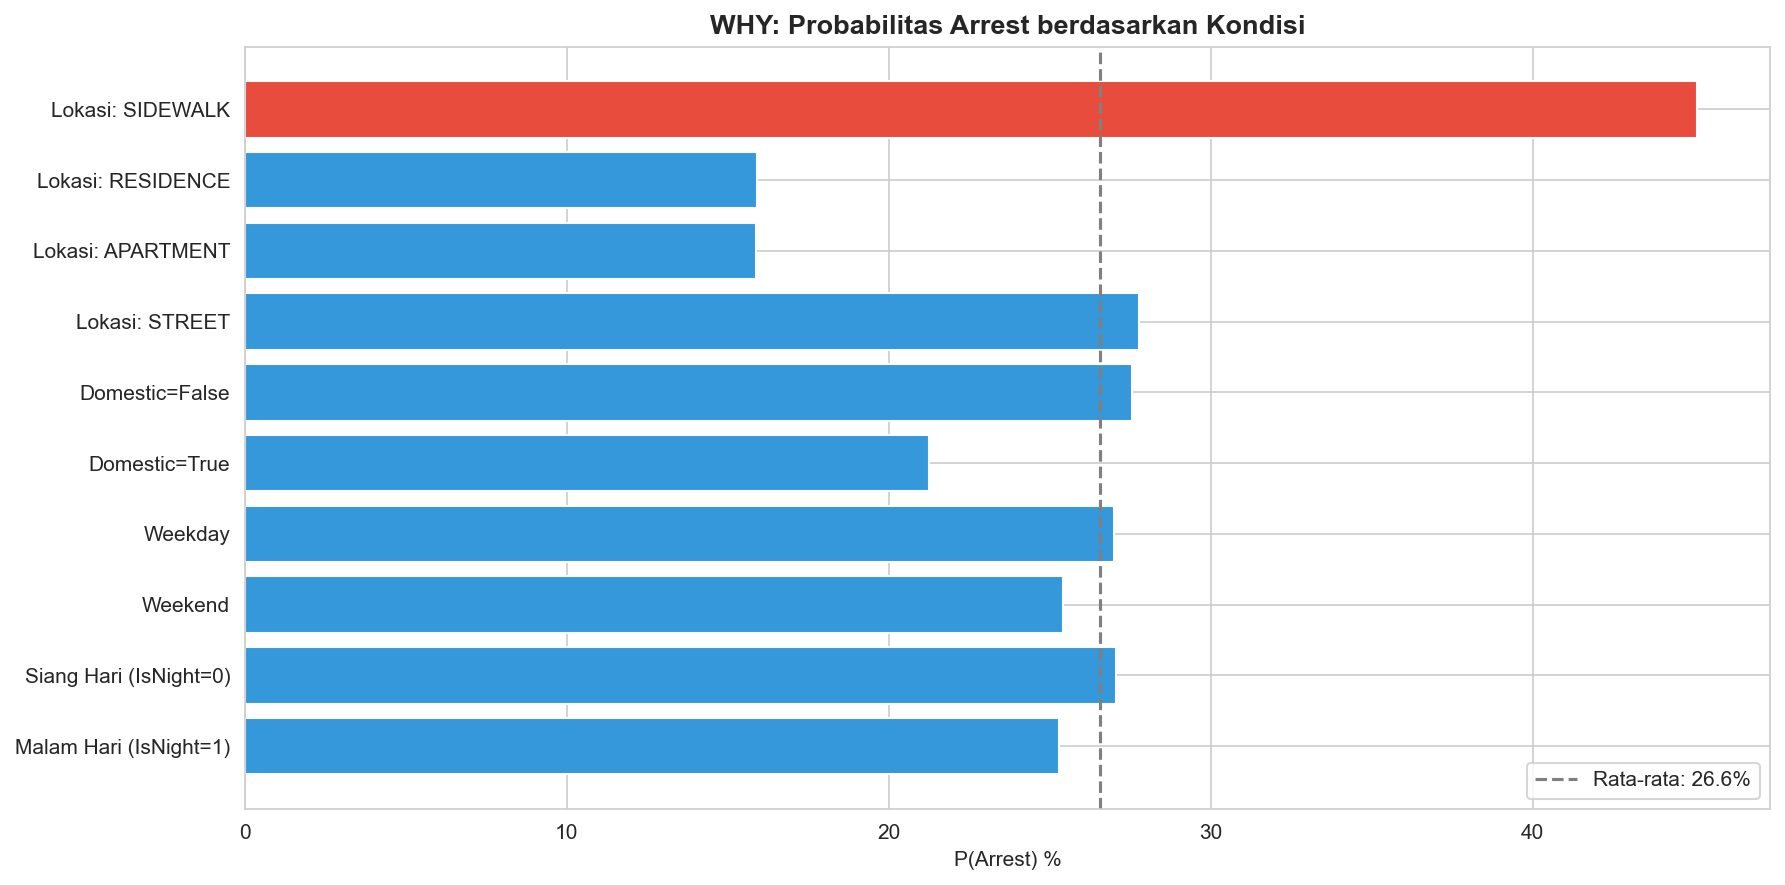

In [11]:
print("\n[5.1] Probabilitas Bersyarat P(Arrest | Kondisi):")
conditions = [
    ('Malam Hari (IsNight=1)', df['IsNight']==1),
    ('Siang Hari (IsNight=0)', df['IsNight']==0),
    ('Weekend', df['IsWeekend']==1),
    ('Weekday', df['IsWeekend']==0),
    ('Domestic=True', df['Domestic']==True),
    ('Domestic=False', df['Domestic']==False),
    ('Lokasi: STREET', df['Location Description']=='STREET'),
    ('Lokasi: APARTMENT', df['Location Description']=='APARTMENT'),
    ('Lokasi: RESIDENCE', df['Location Description']=='RESIDENCE'),
    ('Lokasi: SIDEWALK', df['Location Description']=='SIDEWALK'),
]
print(f"  {'Kondisi':<35s} {'P(Arrest)':>10s}  {'N':>8s}")
print("  " + "-"*55)
cond_data = []
for name, mask in conditions:
    sub = df[mask]
    rate = sub['Arrest'].mean() * 100
    cond_data.append((name, rate, len(sub)))
    print(f"  {name:<35s} {rate:>9.2f}%  {len(sub):>8,}")

fig, ax = plt.subplots(figsize=(12, 6))
names = [c[0] for c in cond_data]
rates = [c[1] for c in cond_data]
colors = ['#e74c3c' if r > 30 else '#3498db' for r in rates]
ax.barh(names, rates, color=colors)
ax.set_title('WHY: Probabilitas Arrest berdasarkan Kondisi', fontsize=13, fontweight='bold')
ax.set_xlabel('P(Arrest) %')
ax.axvline(x=df['Arrest'].mean()*100, color='gray', linestyle='--', label=f'Rata-rata: {df["Arrest"].mean()*100:.1f}%')
ax.legend()
plt.tight_layout()
plt.savefig(f'{OUT}/why_01_conditional_prob.png', bbox_inches='tight')
# plt.close() # Komentari atau hapus baris ini untuk menampilkan plot di notebook
plt.show() # Gunakan plt.show() untuk menampilkan plot secara eksplisit


[5.2] Profil Multi-Feature per Top 5 Crime Type:
  THEFT:
    Arrest Rate: 13.7%
    Domestic Rate: 3.1%
    Night Rate: 20.3%
    Weekend Rate: 26.5%
  BATTERY:
    Arrest Rate: 21.2%
    Domestic Rate: 48.2%
    Night Rate: 32.9%
    Weekend Rate: 31.8%
  CRIMINAL DAMAGE:
    Arrest Rate: 7.2%
    Domestic Rate: 10.5%
    Night Rate: 35.4%
    Weekend Rate: 30.7%
  NARCOTICS:
    Arrest Rate: 99.8%
    Domestic Rate: 0.1%
    Night Rate: 21.5%
    Weekend Rate: 24.1%
  ASSAULT:
    Arrest Rate: 20.2%
    Domestic Rate: 29.5%
    Night Rate: 20.5%
    Weekend Rate: 26.7%


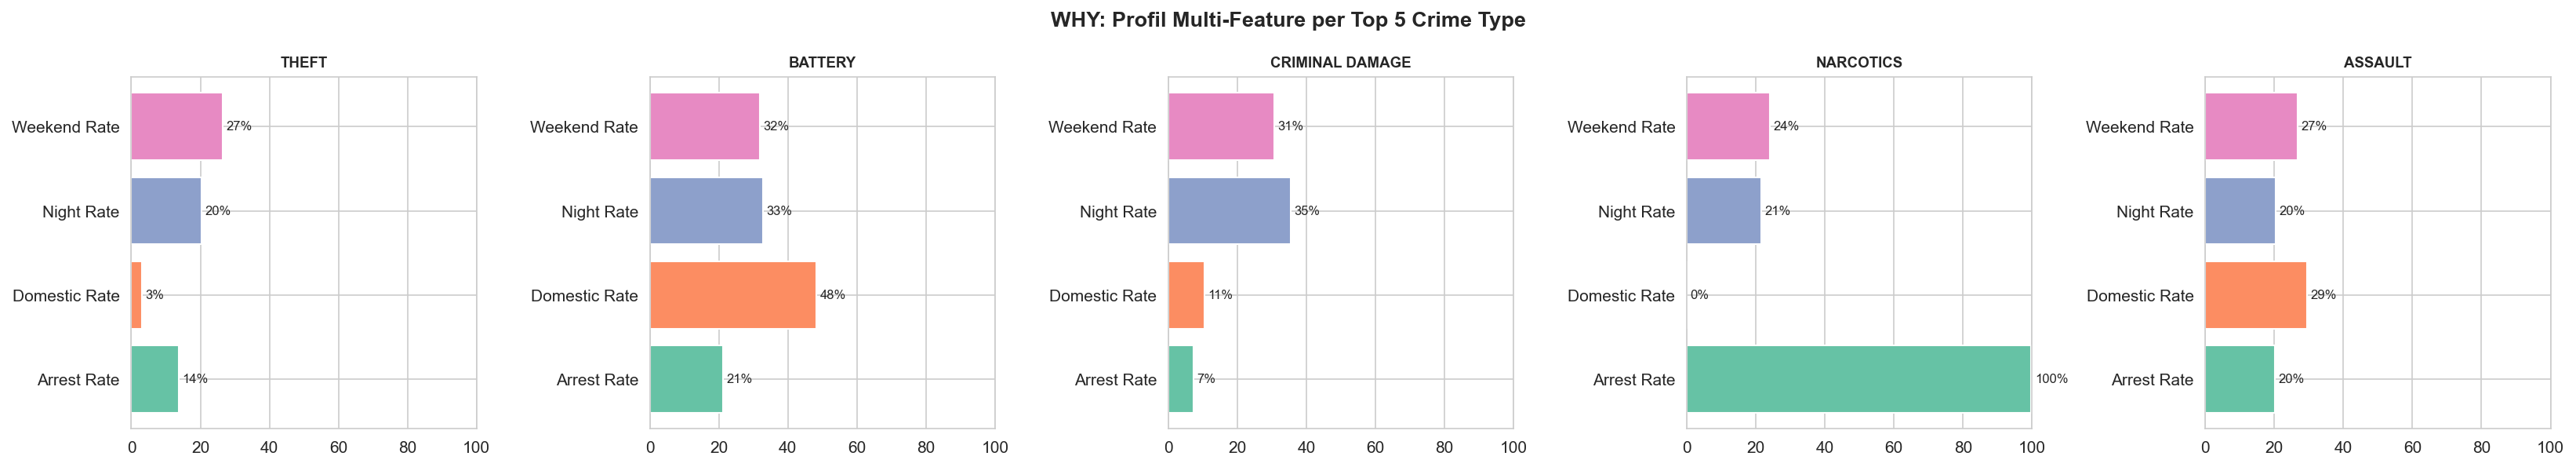

In [12]:
print("\n[5.2] Profil Multi-Feature per Top 5 Crime Type:")
top5 = df['Primary Type'].value_counts().head(5).index.tolist()
metrics = ['Arrest Rate','Domestic Rate','Night Rate','Weekend Rate']

fig, axes = plt.subplots(1, 5, figsize=(22, 4))
profile_data = []
for idx, crime in enumerate(top5):
    sub = df[df['Primary Type']==crime]
    vals = [sub['Arrest'].mean()*100, sub['Domestic'].mean()*100,
            sub['IsNight'].mean()*100, sub['IsWeekend'].mean()*100]
    profile_data.append(vals)
    print(f"  {crime}:")
    for m, v in zip(metrics, vals):
        print(f"    {m}: {v:.1f}%")
    
    axes[idx].barh(metrics, vals, color=sns.color_palette('Set2', 4))
    axes[idx].set_title(crime, fontsize=9, fontweight='bold')
    axes[idx].set_xlim(0, 100)
    for i, v in enumerate(vals):
        axes[idx].text(v+1, i, f'{v:.0f}%', va='center', fontsize=8)

plt.suptitle('WHY: Profil Multi-Feature per Top 5 Crime Type', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUT}/why_02_crime_profiles.png', bbox_inches='tight')
# plt.close()
plt.show()


[5.3] Domestic vs Non-Domestic Comparison:


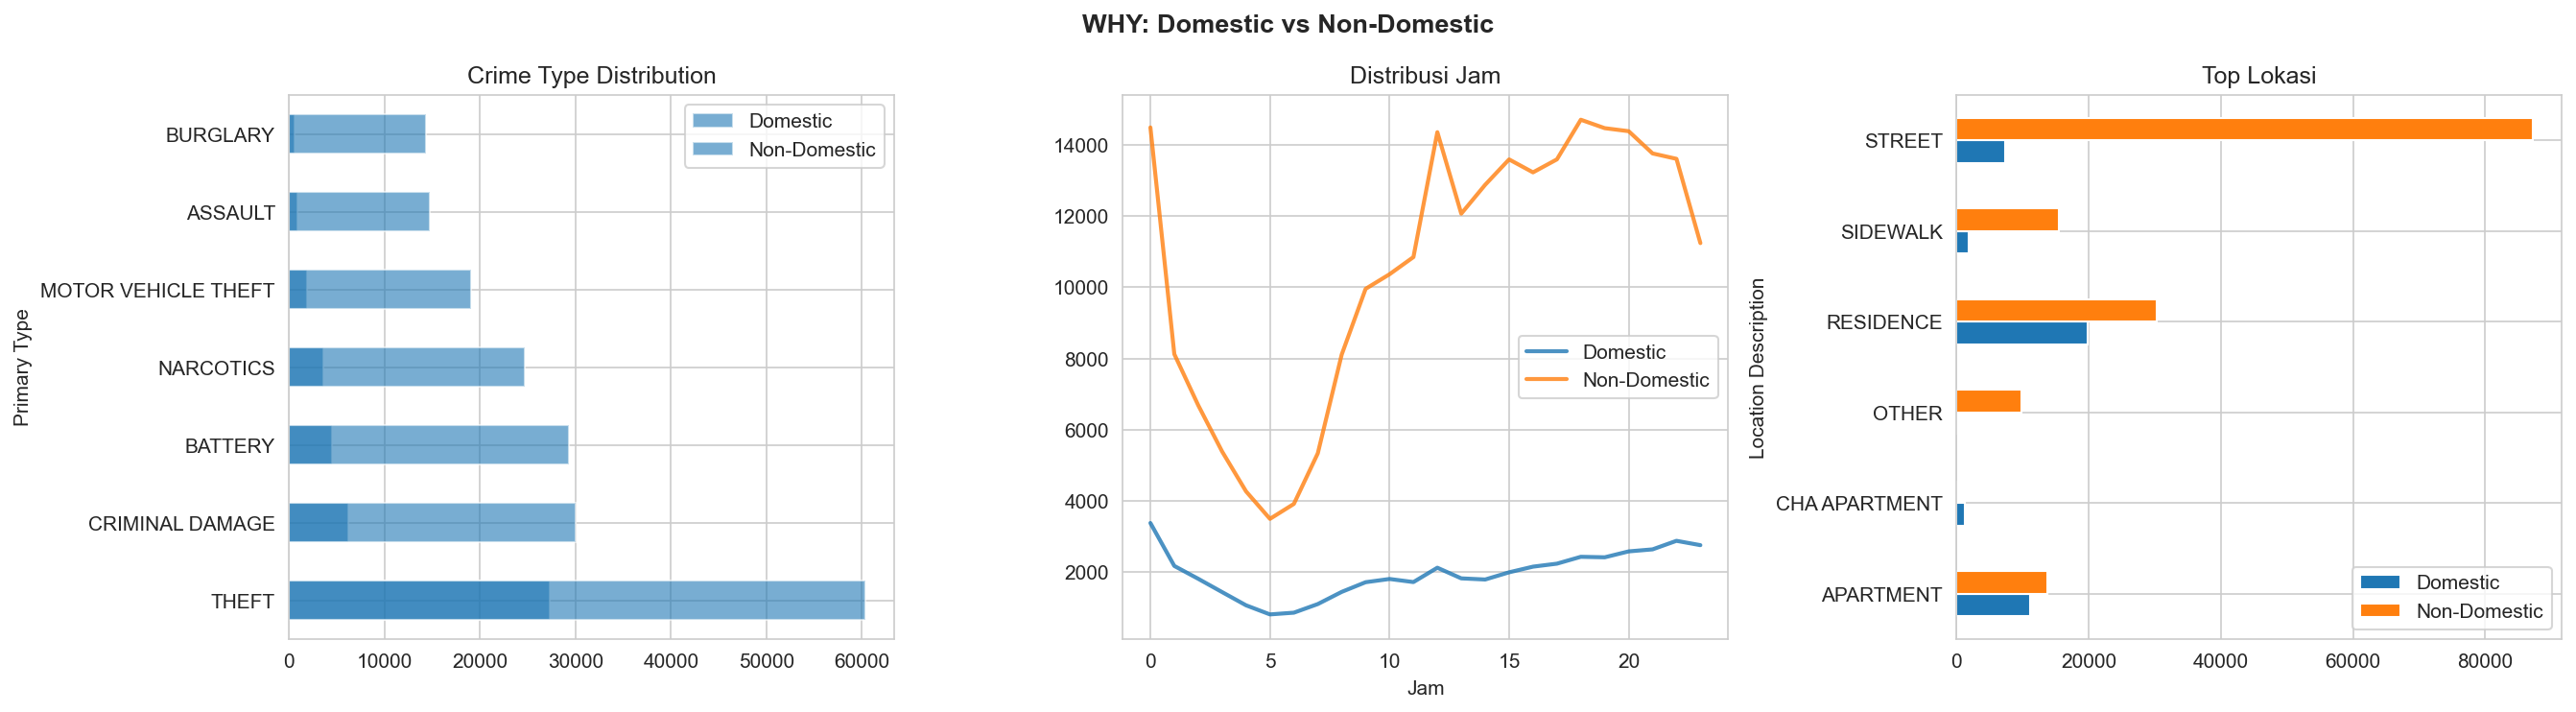

In [13]:
print("\n[5.3] Domestic vs Non-Domestic Comparison:")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (label, mask) in enumerate([('Domestic', df['Domestic']==True), ('Non-Domestic', df['Domestic']==False)]):
    sub = df[mask]
    sub['Primary Type'].value_counts().head(7).plot(kind='barh', ax=axes[0], alpha=0.6, label=label)
    sub['Hour'].value_counts().sort_index().plot(kind='line', ax=axes[1], alpha=0.8, label=label, linewidth=2)

axes[0].set_title('Crime Type Distribution'); axes[0].legend()
axes[1].set_title('Distribusi Jam'); axes[1].legend(); axes[1].set_xlabel('Jam')

dom_loc = df[df['Domestic']==True]['Location Description'].value_counts().head(5)
nondom_loc = df[df['Domestic']==False]['Location Description'].value_counts().head(5)
comp = pd.DataFrame({'Domestic': dom_loc, 'Non-Domestic': nondom_loc}).fillna(0).head(7)
comp.plot(kind='barh', ax=axes[2])
axes[2].set_title('Top Lokasi')

plt.suptitle('WHY: Domestic vs Non-Domestic', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUT}/why_03_domestic_comparison.png', bbox_inches='tight')
# plt.close()
plt.show()


[5.4] Night vs Day - Perubahan Crime Type:
                      Night(%)     Day(%)      Diff
Primary Type                                       
THEFT                15.138756  22.920055 -7.781299
DECEPTIVE PRACTICE    0.000000   4.542514 -4.542514
NARCOTICS             6.346890   8.966266 -2.619376
ASSAULT               5.119617   7.674214 -2.554597
OTHER OFFENSE         3.479665   4.943623 -1.463958
BURGLARY              4.551435   4.967652 -0.416217
MOTOR VEHICLE THEFT   7.600478   5.926525  1.673954
ROBBERY               5.502392   3.426987  2.075405
HOMICIDE              3.965311   0.000000  3.965311
CRIMINAL DAMAGE      14.214115  10.030037  4.184078
BATTERY              22.269139  17.571627  4.697512


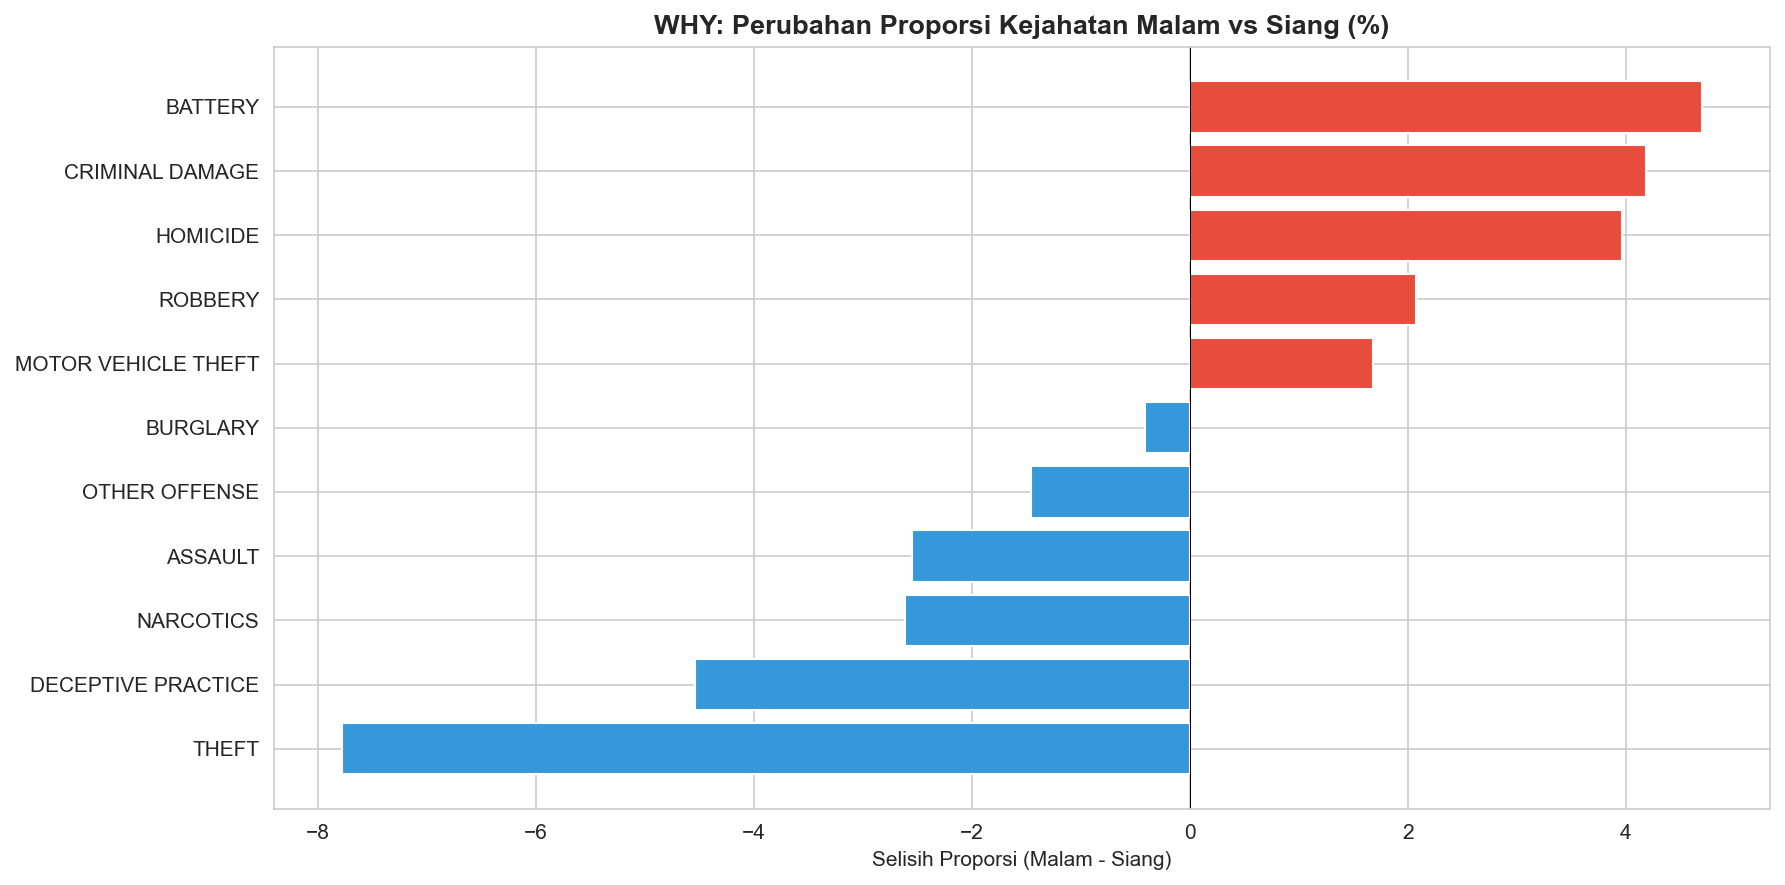

In [14]:
print("\n[5.4] Night vs Day - Perubahan Crime Type:")
night = df[df['IsNight']==1]['Primary Type'].value_counts(normalize=True).head(10) * 100
day = df[df['IsNight']==0]['Primary Type'].value_counts(normalize=True).head(10) * 100
comp_nd = pd.DataFrame({'Night(%)': night, 'Day(%)': day}).fillna(0)
comp_nd['Diff'] = comp_nd['Night(%)'] - comp_nd['Day(%)']
comp_nd = comp_nd.sort_values('Diff')
print(comp_nd.to_string())

fig, ax = plt.subplots(figsize=(12, 6))
colors = ['#e74c3c' if d > 0 else '#3498db' for d in comp_nd['Diff']]
ax.barh(comp_nd.index, comp_nd['Diff'], color=colors)
ax.set_title('WHY: Perubahan Proporsi Kejahatan Malam vs Siang (%)', fontsize=13, fontweight='bold')
ax.set_xlabel('Selisih Proporsi (Malam - Siang)')
ax.axvline(x=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.savefig(f'{OUT}/why_04_night_vs_day.png', bbox_inches='tight')
# plt.close()
plt.show()


[5.5] Correlation Heatmap:


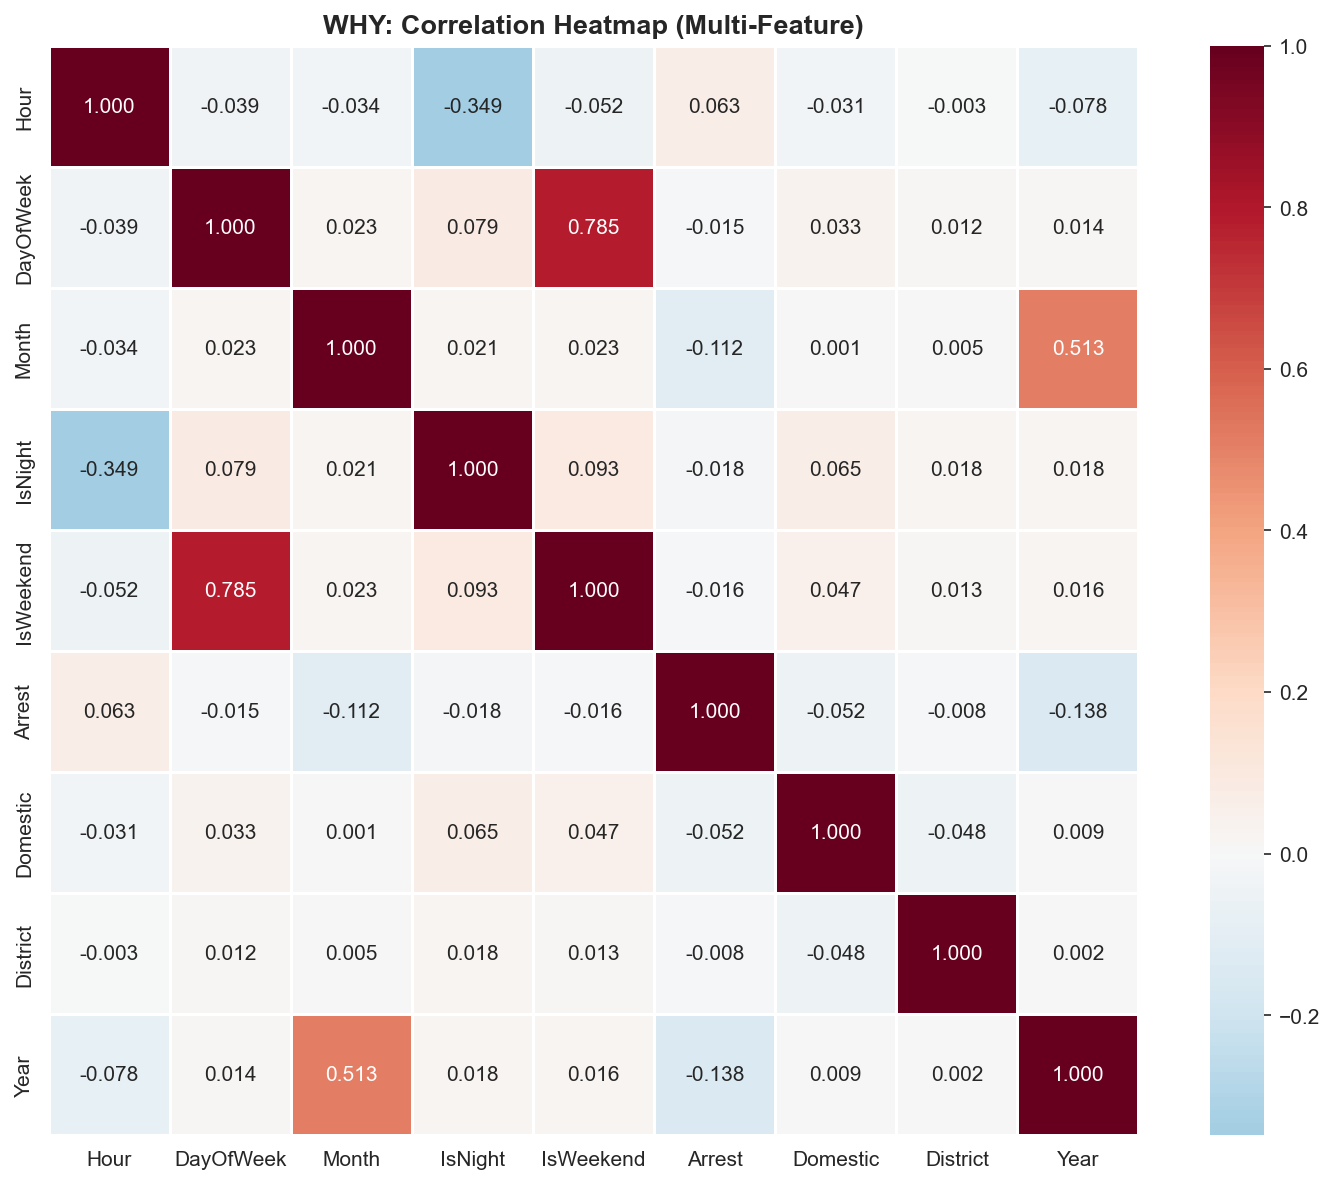

In [15]:
print("\n[5.5] Correlation Heatmap:")
corr_cols = ['Hour','DayOfWeek','Month','IsNight','IsWeekend','Arrest','Domestic','District','Year']
df_num = df[corr_cols].copy()
df_num['Arrest'] = df_num['Arrest'].astype(int)
df_num['Domestic'] = df_num['Domestic'].astype(int)
corr = df_num.corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='RdBu_r', center=0, ax=ax, square=True, linewidths=0.5)
ax.set_title('WHY: Correlation Heatmap (Multi-Feature)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUT}/why_05_correlation.png', bbox_inches='tight')
# plt.close()
plt.show()

In [17]:
print("\n[5.6] Chi-Square Independence Tests:")
chi_tests = [
    ('Arrest x Domestic', 'Arrest', 'Domestic'),
    ('Arrest x IsNight', 'Arrest', 'IsNight'),
    ('Arrest x IsWeekend', 'Arrest', 'IsWeekend'),
]
for name, c1, c2 in chi_tests:
    ct = pd.crosstab(df[c1], df[c2])
    chi2, p, dof, _ = chi2_contingency(ct)
    cramers_v = np.sqrt(chi2 / (len(df) * (min(ct.shape) - 1)))
    sig = 'SIGNIFIKAN' if p < 0.05 else 'TIDAK SIGNIFIKAN'
    print(f"  {name:<25s} Chi2={chi2:>12.1f}  p={p:.2e}  Cramer's V={cramers_v:.4f}  [{sig}]")
print("\n[Saved] why_01 ~ why_05")


[5.6] Chi-Square Independence Tests:
  Arrest x Domestic         Chi2=       802.8  p=1.36e-176  Cramer's V=0.0517  [SIGNIFIKAN]
  Arrest x IsNight          Chi2=        95.8  p=1.28e-22  Cramer's V=0.0179  [SIGNIFIKAN]
  Arrest x IsWeekend        Chi2=        78.9  p=6.37e-19  Cramer's V=0.0162  [SIGNIFIKAN]

[Saved] why_01 ~ why_05
